In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

import cvTools.interaction as cst

# SEGMENTATION - finalpls

In [39]:
img_path = 'data/MEL/ISIC_0032182.jpg'
img = cv.imread(img_path)[1:-1, 1:-1, :]  # some photos have white borders

### CLAHE
clahe = cv.createCLAHE(clipLimit=1, tileGridSize=(10,10))
cl = cv.cvtColor(img, cv.COLOR_BGR2LAB)
cl = cv.dilate(cl, np.ones((3,3), dtype=np.uint8), iterations=2)  # kill hair: either 3x3 it=2, or 5x5
cl = cv.erode(cl, np.ones((3,3), dtype=np.uint8), iterations=2)
cl[..., 0] = clahe.apply(cl[..., 0])
cl = cv.cvtColor(cl, cv.COLOR_LAB2BGR)
# cst.show([img, cl], ['img', 'cl'])


## h thresholding
temp = cv.cvtColor(img, cv.COLOR_BGR2HSV)
_, thresh = cv.threshold(temp[..., 0], 23, 255, cv.THRESH_BINARY_INV)
_, thresh2 = cv.threshold(temp[..., 0], 110, 255, cv.THRESH_BINARY)
thresh = cv.bitwise_or(thresh, thresh2)

### Segmentation
temp = cv.cvtColor(cl, cv.COLOR_BGR2GRAY)
lens = np.zeros_like(temp)
cv.thresholdWithMask(temp, lens, thresh, 10, 255, cv.THRESH_BINARY)  # lens is the new mask of active pxs

rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
cols = [cv.hasNonZero(lens[:, i]) for i in range(lens.shape[1])]
lens = (lens[rows][:, cols])[40:-40, 40:-40].copy()
temp = (temp[rows][:, cols])[40:-40, 40:-40].copy()
cl = (cl[rows][:, cols])[40:-40, 40:-40, :]

## otsu
otsu = np.zeros_like(temp)
cv.thresholdWithMask(temp, otsu, lens, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
rows = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
cols = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
otsu = otsu[rows][:, cols].copy()
cl = cl[rows][:, cols].copy()
# cst.show([thresh, lens, otsu], ['thresh', 'lens', 'otsu'])

### kill small patches
conts, _ = cv.findContours(otsu, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
cxs = []
cys = []
contSave = []
for i, cont in enumerate(conts):
    mom = cv.moments(cont)
    if mom['m00'] < 1e3: continue  # Area    # not guf  or mom['m00'] > 15e4  might wanna go little by little down
    cx = int(mom['m10'] / mom['m00'])  # centroid position
    lim = otsu.shape[1] * .1
    if cx < lim or cx > otsu.shape[1] - lim: continue
    cy = int(mom['m01'] / mom['m00'])
    lim = otsu.shape[1] * .1
    if cy < lim or cy > otsu.shape[0] - lim: continue
    cxs.append(cx)
    cys.append(cy)
    contSave.append(i)

### debugging        remove lines again after stuff
## continue algorithm
if len(contSave) != 0:
    otsu = np.zeros_like(otsu)
    for cont in contSave: cv.drawContours(otsu, conts, cont, 255, -1)
    rows = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
    cols = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
    seg = cv.bitwise_and(cl, cl, mask=otsu)[rows][:,cols]
    segL = cv.cvtColor(seg, cv.COLOR_BGR2LAB)
    # cst.show([img, temp, otsu, seg], ['img', 'filter', 'otsu', 'res'])
    
    ### Filtering
    cl = cv.bilateralFilter(segL, d=30, sigmaColor=20, sigmaSpace=10)
    # cl = cv.cvtColor(cl, cv.COLOR_LAB2BGR)
    # cst.show([img, seg, cv.cvtColor(cl, cv.COLOR_LAB2BGR)], ['original', 'segmented', 'bil'])
else: print('Damn')

In [40]:
orb = cv.SIFT_create()
cl_BGR = cv.cvtColor(cl, cv.COLOR_LAB2BGR)
kp, des = orb.detectAndCompute(cl[..., 0], otsu)
# cst.show([img, cl_BGR], ['original', 'pre-processed'])
out = np.copy(cl_BGR)
out = cv.drawKeypoints(cl_BGR, kp, out, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
cst.show([img, out], ['img', 'kp'])
len(kp)

347

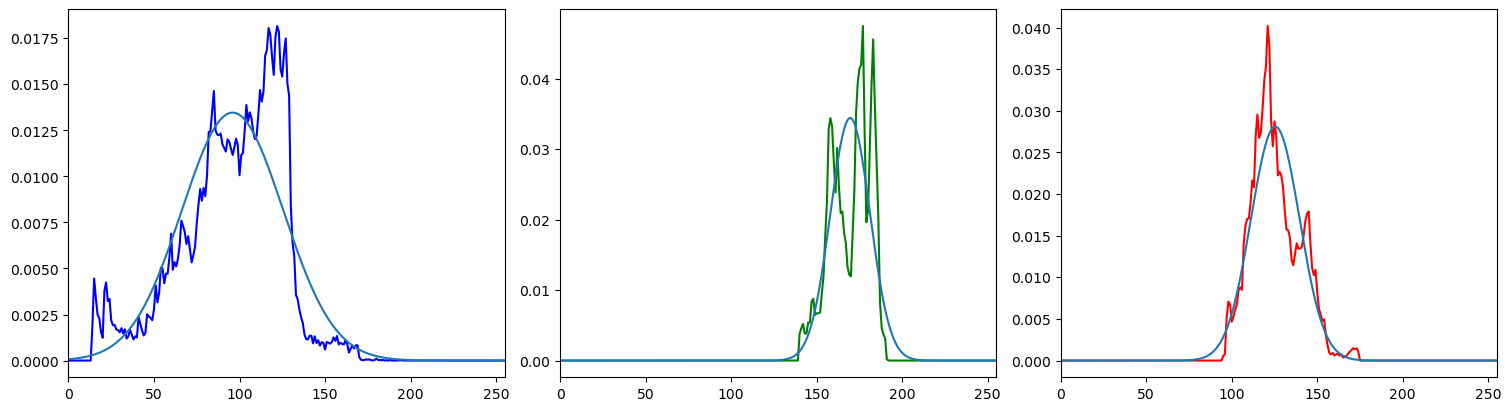

In [33]:
from scipy.stats import norm

means, stds = cv.meanStdDev(cl, mask=otsu[rows][:, cols])
hists = [cv.calcHist([cl], [channel], otsu[rows][:, cols], [256], [0, 256]) for channel in range(3)]

xs = np.linspace(0,255,500)
fig, ax = plt.subplots(1, 3, figsize=(15,4), layout='constrained')
for i, c in enumerate(('b', 'g', 'r')):
    distro = norm(loc=means[i], scale=stds[i])
    ax[i].plot(hists[i]/ cv.countNonZero(otsu[rows][:, cols]), c=c)
    ax[i].plot(xs, distro.pdf(xs))
    ax[i].set_xlim((0, 255))
plt.show()

# Hist eq

In [149]:
img_path = 'data/MEL/ISIC_0000295.jpg'
img = cv.imread(img_path)

### Segmentation
temp = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
_, lens = cv.threshold(temp, 10, 255, cv.THRESH_BINARY) # throw away lens borders
rows = [cv.hasNonZero(lens[i]) for i in range(lens.shape[0])]
cols = [cv.hasNonZero(lens[:,i]) for i in range(lens.shape[1])]
temp = cv.add(temp, cv.bitwise_not(lens))[rows][:, cols]  # color the lens white for otsu
temp = cv.dilate(temp, np.ones((5,5), dtype=np.uint8),iterations=1)  # kill hair

## otsu
_, otsu = cv.threshold(temp, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
rows2 = [cv.hasNonZero(otsu[i]) for i in range(otsu.shape[0])]
cols2 = [cv.hasNonZero(otsu[:,i]) for i in range(otsu.shape[1])]
seg = cv.bitwise_and(img[rows][:, cols], img[rows][:, cols], mask=otsu)[rows2][:, cols2]
# cst.show([img, temp, otsu, seg], ['img', 'filter', 'otsu', 'res'])

### Filtering
cl = cv.bilateralFilter(seg, d=9, sigmaColor=1, sigmaSpace=10)
# cst.show([img, cl], ['original', 'bil'])

r, c = np.nonzero(otsu[rows2][:, cols2] == 255)
seg_LAB = cv.cvtColor(seg, cv.COLOR_BGR2LAB)
eq = cv.equalizeHist((seg_LAB[..., 0])[r, c])


img2 = seg_LAB.copy()
for i, C in enumerate(zip(r, c)):
    img2[C[0], C[1]][0] = eq[i][0]
img2 = cv.cvtColor(img2, cv.COLOR_LAB2BGR)
cst.show([img, img2, cl], ['original', 'eq', 'bil'])

In [16]:
prova = thresh[rows][:, cols]
active = cv.countNonZero(prova)
vert = cv.flip(prova, 0)
hor = cv.flip(prova, 1)
center = cv.flip(hor, 0)
for i in (vert, hor, center): print(cv.countNonZero(cv.bitwise_and(prova, i)) / active)

0.6231950062957109
0.5061483644546843
0.5281431671444263
